# Agrupamiento espectral

Importemos las librerías.

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

Utilizaremos los mismos ejemplos de la matriz Laplaciana.

## Ejemplo 3

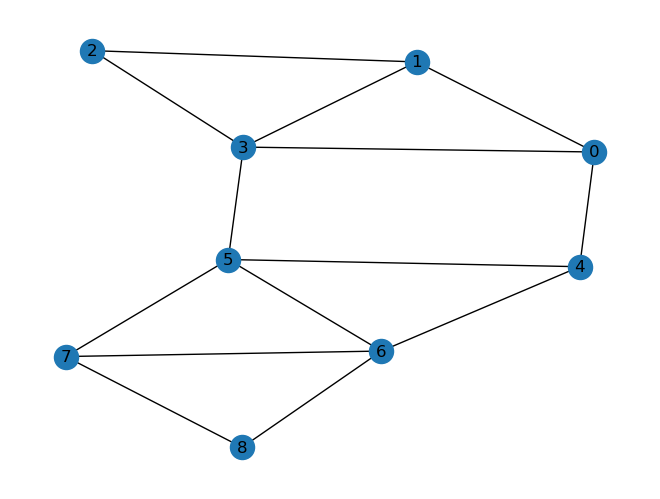

In [2]:
G3=nx.Graph()

for i in range(9):
    G3.add_node(i)

edges=[(0,1),(1,2),(2,3),(3,1),(3,0),(4,5),(5,6),(6,4),(7,8),(6,7),(0,4),(3,5),(5,7),(6,8)]
G3.add_edges_from(edges)
layout=nx.kamada_kawai_layout(G3)
nx.draw(G3,layout, with_labels=True)

Encontramos la Laplaciana

In [3]:
L3=nx.laplacian_matrix(G3)
print(L3.toarray())

[[ 3 -1  0 -1 -1  0  0  0  0]
 [-1  3 -1 -1  0  0  0  0  0]
 [ 0 -1  2 -1  0  0  0  0  0]
 [-1 -1 -1  4  0 -1  0  0  0]
 [-1  0  0  0  3 -1 -1  0  0]
 [ 0  0  0 -1 -1  4 -1 -1  0]
 [ 0  0  0  0 -1 -1  4 -1 -1]
 [ 0  0  0  0  0 -1 -1  3 -1]
 [ 0  0  0  0  0  0 -1 -1  2]]


Calculamos los eigenvalores y eigenvectores

In [4]:
eigenvalores, eigenvectores=np.linalg.eig(L3.toarray())

Buscamos el eigenvalor $\lambda_2$ más pequeño distinto de cero. Como la red es conexa, será el segundo eigenvalor.

In [5]:
eigenvalores

array([-8.88178420e-16,  5.40472459e-01,  5.88291774e+00,  1.80647291e+00,
        5.19352709e+00,  2.70503710e+00,  3.34296213e+00,  4.29496290e+00,
        4.23364767e+00])

Ahora buscamos el eigenvector correspondiente.

In [6]:
eigenvectores

array([[-3.33333333e-01, -2.41125060e-01,  2.78798855e-01,
         3.83219052e-01,  2.45841533e-01, -5.07860853e-01,
        -4.07138931e-02,  5.33650121e-01,  3.68940624e-02],
       [-3.33333333e-01, -4.00669666e-01,  6.13011716e-02,
        -9.64386475e-02, -1.30739395e-01, -2.96417768e-01,
        -2.58956429e-01, -6.21082366e-01,  3.96908606e-01],
       [-3.33333333e-01, -4.65537656e-01,  1.36744768e-01,
        -4.98321190e-01,  4.09388716e-02,  4.20428609e-01,
         3.77389439e-01,  2.70628499e-01,  1.05079301e-01],
       [-3.33333333e-01, -2.78795364e-01, -5.92269858e-01,
        -7.49894175e-16, -1.52961350e-15, -1.62380578e-16,
        -2.47863297e-01, -5.67100926e-15, -6.31618742e-01],
       [-3.33333333e-01,  8.64113047e-02, -2.72785477e-01,
         5.53820966e-01, -4.08520667e-01,  1.46617658e-01,
         5.20783050e-01, -6.99747429e-02,  1.89195861e-01],
       [-3.33333333e-01,  1.42832143e-01,  6.38350625e-01,
         2.11540785e-01, -1.56041010e-01,  3.838500

Tenemos una matriz en la que las columnas son los eigenvectores. Buscamos la segunda columna.

In [7]:
eigenvectores[:,1]

array([-0.24112506, -0.40066967, -0.46553766, -0.27879536,  0.0864113 ,
        0.14283214,  0.3108239 ,  0.37569189,  0.47036851])

Los nodos correspondientes a las entradas negativas se agrupan, en este caso los nodos 0,1,2,3.

Veamos otra forma. Verificamos con el espectro que el segundo eigenvalor es distinto de cero.

In [8]:
nx.laplacian_spectrum(G3)

array([9.05525654e-16, 5.40472459e-01, 1.80647291e+00, 2.70503710e+00,
       3.34296213e+00, 4.23364767e+00, 4.29496290e+00, 5.19352709e+00,
       5.88291774e+00])

Usamos la función "nx.fiedler_vector" para encontrar el eigenvector correspondiente.

In [9]:
nx.fiedler_vector(G3)

array([-0.24112506, -0.40066967, -0.46553766, -0.27879536,  0.08641131,
        0.14283214,  0.3108239 ,  0.37569189,  0.4703685 ])

Nuevamente, los nodos correspondientes a los valores negativos se agrupan. Sabiendo que son 4 nodos, podemos revisar el ordenamiento espectral, lo que nos diría que los primeros 4 nodos se agrupan.

In [10]:
nx.spectral_ordering(G3)

[2, 1, 3, 0, 4, 5, 6, 7, 8]

## Ejemplo 4

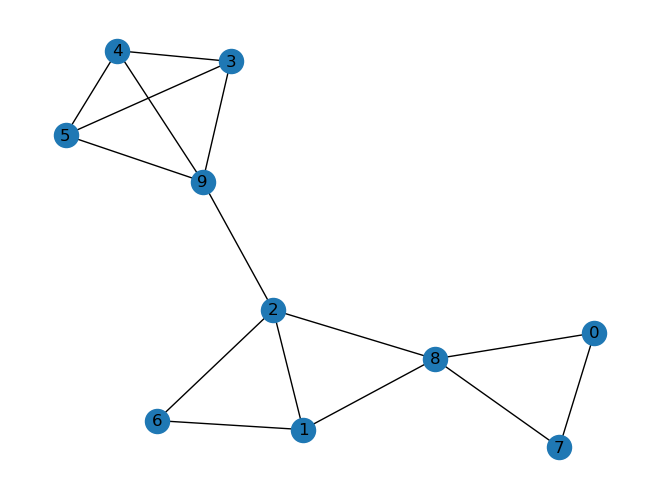

In [11]:
G4=nx.Graph()

for i in range(10):
    G4.add_node(i)

edges=[(0,8),(0,7),(7,8),(1,8),(2,8),(1,2),(1,6),(2,6),(2,9),(9,3),(3,4),(3,5),(4,5),(4,9),(9,5)]
G4.add_edges_from(edges)
layout=nx.kamada_kawai_layout(G4)
nx.draw(G4,layout, with_labels=True)

Similarmente, calculamos los eigenvalores (para checar que la red es conexa), buscamos el veector correspondiente al eigenvalor más pequeño distinto de cero y agrupamos los correspondientes a entradas negativas.

In [12]:
L4=nx.laplacian_matrix(G4)
print(L4.toarray())

[[ 2  0  0  0  0  0  0 -1 -1  0]
 [ 0  3 -1  0  0  0 -1  0 -1  0]
 [ 0 -1  4  0  0  0 -1  0 -1 -1]
 [ 0  0  0  3 -1 -1  0  0  0 -1]
 [ 0  0  0 -1  3 -1  0  0  0 -1]
 [ 0  0  0 -1 -1  3  0  0  0 -1]
 [ 0 -1 -1  0  0  0  2  0  0  0]
 [-1  0  0  0  0  0  0  2 -1  0]
 [-1 -1 -1  0  0  0  0 -1  4  0]
 [ 0  0 -1 -1 -1 -1  0  0  0  4]]


In [13]:
eigenvalores, eigenvectores=np.linalg.eig(L4.toarray())

In [14]:
eigenvalores

array([-5.55111512e-16,  2.60171357e-01,  8.63783964e-01,  5.81535737e+00,
        5.00000000e+00,  3.00000000e+00,  3.06068731e+00,  4.00000000e+00,
        4.00000000e+00,  4.00000000e+00])

In [15]:
eigenvectores[:,1]

array([ 0.37728044,  0.19645838,  0.09285246, -0.39822187, -0.39822187,
       -0.39822187,  0.16628698,  0.37728044,  0.27912287, -0.29461595])

En este caso, serían los nodos 3, 4, 5,9.

Veamos la segunda forma. Veamos el espectro Laplaciano y calculamos el vector de Fiedler.

In [16]:
nx.laplacian_spectrum(G4)

array([3.50202596e-17, 2.60171357e-01, 8.63783964e-01, 3.00000000e+00,
       3.06068731e+00, 4.00000000e+00, 4.00000000e+00, 4.00000000e+00,
       5.00000000e+00, 5.81535737e+00])

In [17]:
nx.fiedler_vector(G4)

array([-0.37728045, -0.19645837, -0.09285245,  0.39822187,  0.39822187,
        0.39822187, -0.16628696, -0.37728045, -0.27912287,  0.29461595])

Los valores negativos corresponden a 0,1,2,6,7,8. Sabiendo que hay 6 valores negativos, checamos el orden espectral.

In [18]:
nx.spectral_ordering(G4)

[0, 7, 8, 1, 6, 2, 9, 4, 5, 3]

Los primeros 6 nodos se agrupan.

Podemos también usar la función "spectral_bisection":

In [19]:
nx.spectral_bisection(G4)

({0, 1, 2, 6, 7, 8}, {3, 4, 5, 9})

Consideremos la subgráfica formada por el primer grupo:

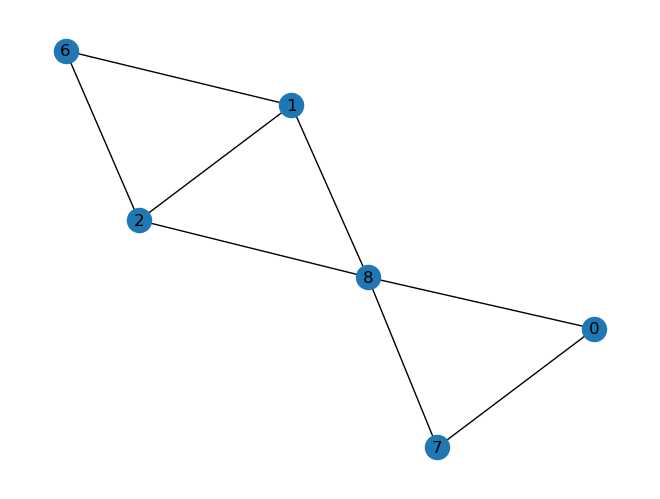

In [20]:
SG=G4.subgraph([0,1,2,6,7,8])
layout=nx.kamada_kawai_layout(SG)
nx.draw(SG,layout, with_labels=True)

Vemos que también se podría dividir. Hagámoslo.

In [21]:
LS=nx.laplacian_matrix(SG)
print(LS.toarray())

[[ 2  0  0  0 -1 -1]
 [ 0  3 -1 -1  0 -1]
 [ 0 -1  3 -1  0 -1]
 [ 0 -1 -1  2  0  0]
 [-1  0  0  0  2 -1]
 [-1 -1 -1  0 -1  4]]


In [22]:
nx.laplacian_spectrum(SG)

array([2.16298333e-17, 7.63932023e-01, 3.00000000e+00, 3.00000000e+00,
       4.00000000e+00, 5.23606798e+00])

In [23]:
nx.fiedler_vector(SG)

array([-0.51166728,  0.31622776,  0.31622776,  0.51166728, -0.51166727,
       -0.12078826])

In [24]:
nx.spectral_ordering(SG)

[0, 7, 8, 1, 2, 6]

In [25]:
nx.spectral_bisection(SG)

({0, 7, 8}, {1, 2, 6})

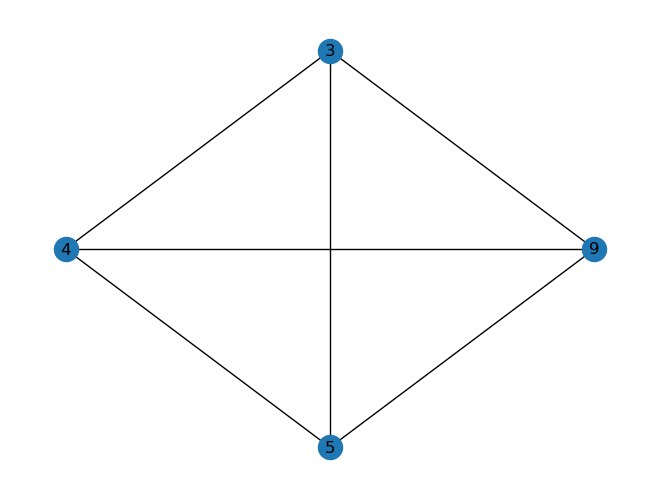

In [26]:
SG1=G4.subgraph([3,4,5,9])
layout=nx.kamada_kawai_layout(SG1)
nx.draw(SG1,layout, with_labels=True)

In [27]:
nx.laplacian_spectrum(SG1)

array([2.22044605e-16, 4.00000000e+00, 4.00000000e+00, 4.00000000e+00])

En este caso $\lambda_2$ es grande, no es cercano a cero. Es un indicativo que será difícil bisectar la red.